# Exploration — Aviation Risk V2

Analyse exploratoire des données de trafic aérien (OpenSky Network).  
Pipeline : ingestion → preprocessing → feature engineering → rule-based scoring → Isolation Forest.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df = pd.read_csv("../data/processed/benchmark.csv")
df.head()

,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,...,is_descending,vertical_rate_abs,vertical_anomaly,lat_bin,lon_bin,risk_score,risk_level,justification,anomaly_score,anomaly_flag
0,ab1644,UAL2250,United States,2026-04-29 13:24:00+00:00,1777469040,-98.2192,29.7789,2727.96,False,152.28,...,1,6.83,0,11,7,8.9,NORMAL,Ecart baro/géo élevé,20.6,0
1,e8027d,LPE2081,Chile,2026-04-29 13:23:15+00:00,1777468995,-76.3633,-6.5644,502.92,False,72.57,...,1,3.58,0,5,9,5.0,NORMAL,Aucune anomalie détectée,51.9,0
2,39de4b,TVF27CR,France,2026-04-29 13:24:00+00:00,1777469041,1.0369,46.5613,11269.98,False,218.89,...,1,0.33,0,14,17,3.9,NORMAL,Ecart baro/géo élevé,3.8,0
3,39de4a,TVF77CG,France,2026-04-29 13:24:01+00:00,1777469041,11.3233,55.9764,11887.20,False,198.55,...,0,0.00,0,15,19,1.5,NORMAL,Aucune anomalie détectée,25.4,0
4,aa9321,UAL97,United States,2026-04-29 13:24:01+00:00,1777469041,-122.2971,37.5885,297.18,False,81.10,...,1,3.90,0,12,5,3.9,NORMAL,Aucune anomalie détectée,26.0,0


In [3]:
print(f"Shape : {df.shape}")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nNulls :\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape : (9503, 34)

Types :
icao24                   str
callsign                 str
origin_country           str
time_position            str
last_contact           int64
longitude            float64
latitude             float64
baro_altitude        float64
on_ground               bool
velocity             float64
true_track           float64
vertical_rate        float64
sensors              float64
geo_altitude         float64
squawk               float64
spi                     bool
position_source        int64
snapshot_time            str
speed_ms             float64
speed_kmh            float64
speed_anomaly          int64
altitude_diff        float64
altitude_anomaly       int64
is_climbing            int64
is_descending          int64
vertical_rate_abs    float64
vertical_anomaly       int64
lat_bin                int64
lon_bin                int64
risk_score           float64
risk_level               str
justification            str
anomaly_score        float64
anomaly_flag   

## Distribution des risques

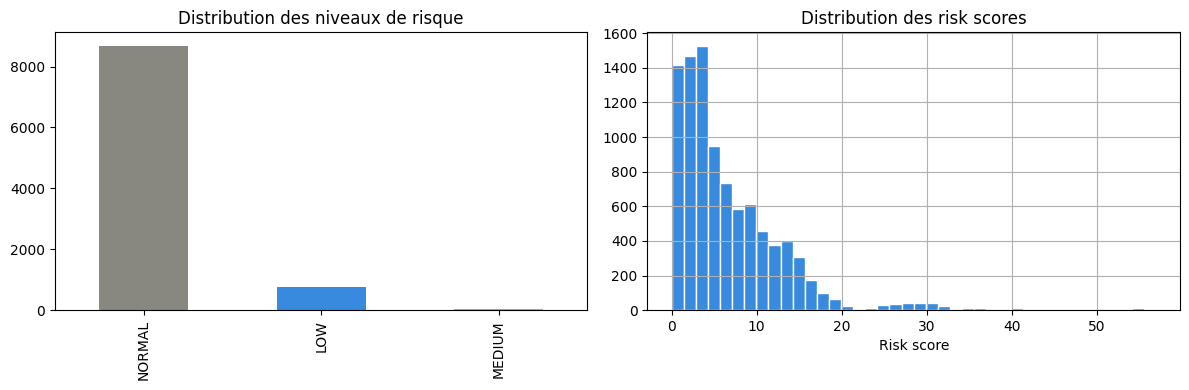

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["risk_level"].value_counts().plot(kind="bar", ax=axes[0], color=["#888780", "#378ADD", "#EF9F27", "#E24B4A"])
axes[0].set_title("Distribution des niveaux de risque")
axes[0].set_xlabel("")

df["risk_score"].hist(bins=40, ax=axes[1], color="#378ADD", edgecolor="white")
axes[1].set_title("Distribution des risk scores")
axes[1].set_xlabel("Risk score")

plt.tight_layout()
plt.show()

## Corrélation rule-based vs Isolation Forest

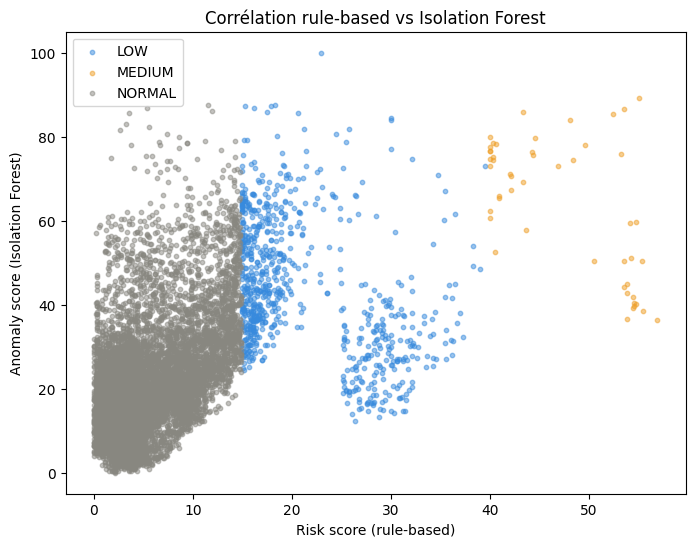

In [5]:
plt.figure(figsize=(8, 6))
colors = {"HIGH": "#E24B4A", "MEDIUM": "#EF9F27", "LOW": "#378ADD", "NORMAL": "#888780"}

for level, group in df.groupby("risk_level"):
    plt.scatter(group["risk_score"], group["anomaly_score"], 
                c=colors[level], label=level, alpha=0.5, s=10)

plt.xlabel("Risk score (rule-based)")
plt.ylabel("Anomaly score (Isolation Forest)")
plt.title("Corrélation rule-based vs Isolation Forest")
plt.legend()
plt.show()

## Top pays à risque

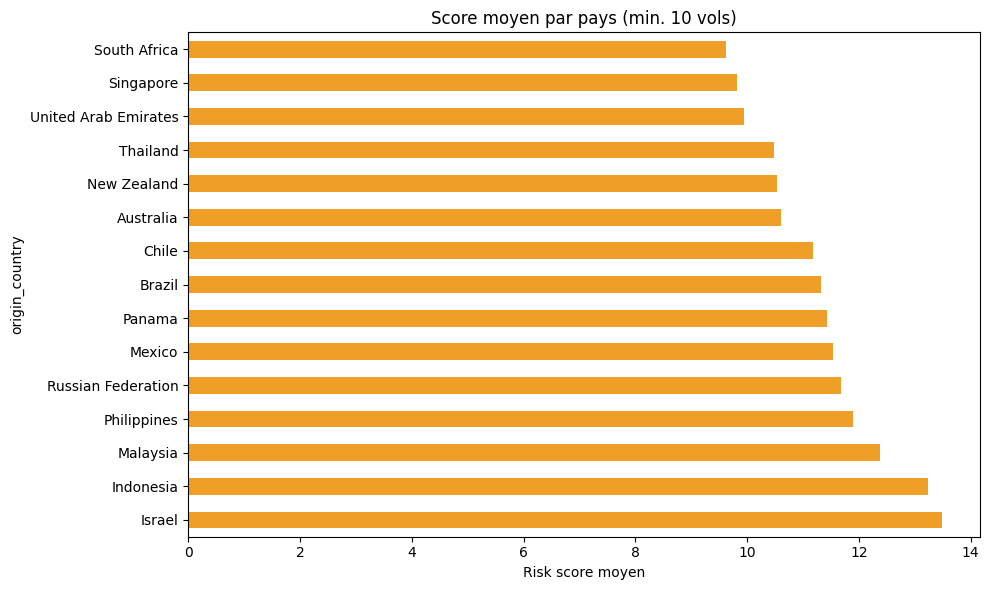

In [6]:
top = (df.groupby("origin_country")["risk_score"]
       .agg(["mean", "count"])
       .query("count >= 10")
       .sort_values("mean", ascending=False)
       .head(15))

top["mean"].plot(kind="barh", figsize=(10, 6), color="#EF9F27")
plt.title("Score moyen par pays (min. 10 vols)")
plt.xlabel("Risk score moyen")
plt.tight_layout()
plt.show()

In [7]:
total = len(df)
normal_pct = (df["risk_level"] == "NORMAL").sum() / total * 100
agreement = (df["anomaly_flag"] == df["risk_level"].isin(["HIGH", "MEDIUM"]).astype(int)).mean() * 100

print(f"Vols analysés : {total:,}")
print(f"Classés NORMAL : {normal_pct:.1f}%")
print(f"Accord rule-based / IF : {agreement:.1f}%")
print(f"Divergences : {100 - agreement:.1f}%")
print(f"Colonne sensors nulle : {df['sensors'].isna().sum() / total * 100:.0f}%")

Vols analysés : 9,503
Classés NORMAL : 91.4%
Accord rule-based / IF : 98.1%
Divergences : 1.9%
Colonne sensors nulle : 100%


## Conclusions

- **9 503 vols** analysés, **91.4%** classés NORMAL — cohérent avec la rareté des anomalies en aviation commerciale
- **98.1% d'accord** entre le scoring rule-based et l'Isolation Forest — valide la pertinence des règles physiques
- Les divergences (1.9%) sont les cas les plus intéressants à investiguer
- La colonne `sensors` est vide sur 100% des données — ignorée dans l'analyse